In [59]:
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [60]:
iris = sns.load_dataset('iris')
X = iris.drop(columns=['species'])
y_true = iris['species'].astype('category').cat.codes

X_scaled = StandardScaler().fit_transform(X)

In [61]:
def purity_score(y_true, y_pred):
    y_true = np.array(y_true)
    mask = y_pred != -1  # ignore DBSCAN noise points
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    clusters = np.unique(y_pred)
    total = 0
    for cluster in clusters:
        indices = np.where(y_pred == cluster)[0]
        true_labels = y_true[indices]
        majority_label = mode(true_labels, keepdims=True)[0][0]
        total += np.sum(true_labels == majority_label)
    return total / len(y_true)

In [62]:
# plot the clusterings using PCA
def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis', s=40)
    plt.title(title)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.grid(True)

K-Means Results:
Silhouette Score: 0.582
Purity Score: 0.667



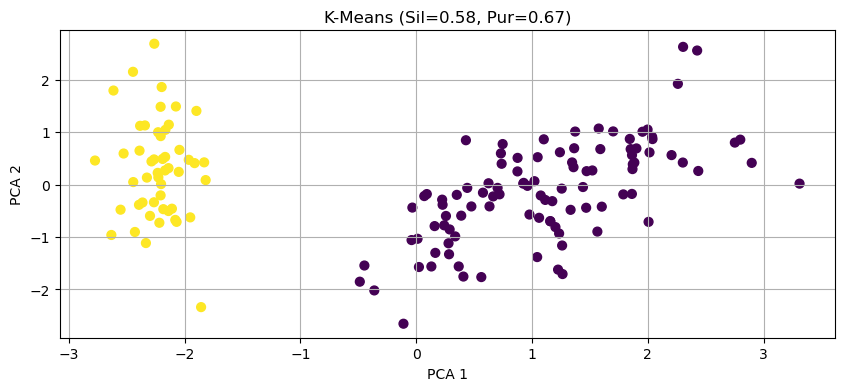

In [63]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_purity = purity_score(y_true, kmeans_labels)

print("K-Means Results:")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Purity Score: {kmeans_purity:.3f}\n")

plt.figure(figsize=(10, 4))
plot_clusters(X_scaled, kmeans_labels, f"K-Means (Sil={kmeans_silhouette:.2f}, Pur={kmeans_purity:.2f})")

Agglomerative Clustering Results:
Silhouette Score: 0.577
Purity Score: 0.660



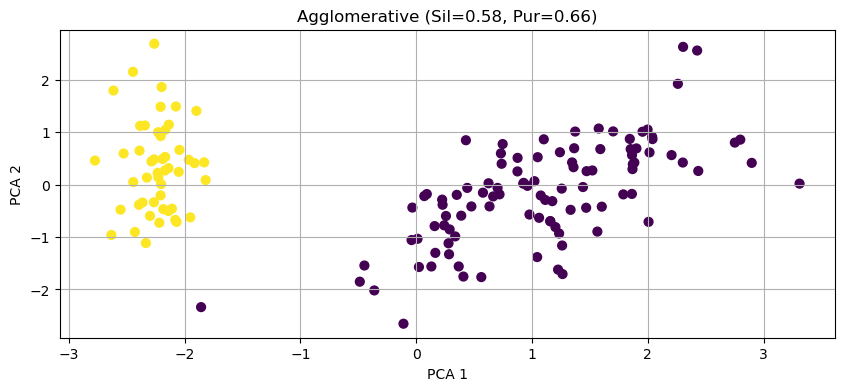

In [64]:
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_scaled)
agg_silhouette = silhouette_score(X_scaled, agg_labels)
agg_purity = purity_score(y_true, agg_labels)

print("Agglomerative Clustering Results:")
print(f"Silhouette Score: {agg_silhouette:.3f}")
print(f"Purity Score: {agg_purity:.3f}\n")

plt.figure(figsize=(10, 4))
plot_clusters(X_scaled, agg_labels, f"Agglomerative (Sil={agg_silhouette:.2f}, Pur={agg_purity:.2f})")

DBSCAN Results:
Silhouette Score: 0.5979413783542474
Purity Score: 0.678


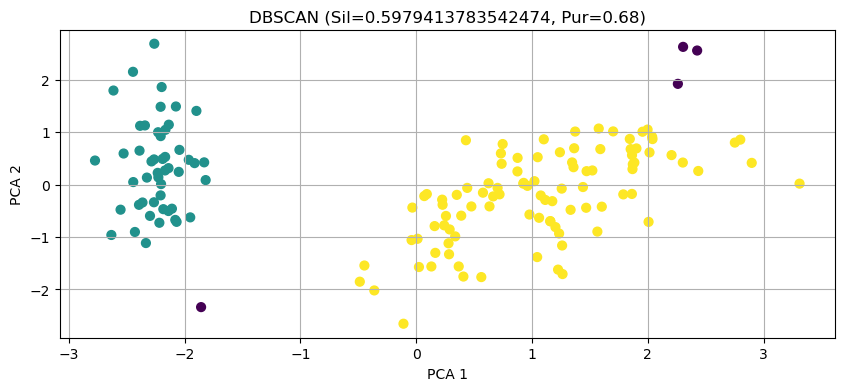

In [65]:
dbscan = DBSCAN(eps=0.85, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
if len(set(dbscan_labels)) > 1 and np.any(dbscan_labels != -1):
    dbscan_silhouette = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    dbscan_silhouette = "N/A (too few clusters or all noise)"
dbscan_purity = purity_score(y_true, dbscan_labels)

print("DBSCAN Results:")
print(f"Silhouette Score: {dbscan_silhouette}")
print(f"Purity Score: {dbscan_purity:.3f}")

plt.figure(figsize=(10, 4))
plot_clusters(X_scaled, dbscan_labels, f"DBSCAN (Sil={dbscan_silhouette}, Pur={dbscan_purity:.2f})")